# ParkinDraw AI — Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the **NewHandPD** dataset for AI-assisted Parkinson's Disease screening using drawing analysis (**Circle**, **Meander**, and **Spiral**).

> **Crucial Integrity Rule**: **Only the Development Set is analyzed.**
> The holdout subjects defined in `data/splits/holdout.csv` are strictly locked and excluded from all cells to prevent visual data leakage prior to final model evaluation. Their exact count is printed in Section 1 rather than quoted here, so this text cannot drift after a re-split.
>
> The single exception is the duplicate scan in Section 4, which reads file *hashes* across the full manifest. That is deliberate: a duplicate straddling the dev/holdout boundary is invisible to a dev-only check, and hashes reveal nothing about image content.

## 0 - Import Libraries

We import standard data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `PIL`) and the project dataset module.

### Discussion
A single `SEED` constant is defined here and used by every sampling operation in this notebook, so re-running it always yields the same figures. File parsing logic is not re-implemented: we rely on `parkindraw.data.dataset.build_manifest` to keep a single source of truth for parsing rules across the project. All analysis below uses only `numpy`/`pandas`, so this notebook needs no dependency beyond the `eda` extra.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from parkindraw.data.dataset import build_manifest

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

SEED = 42

# Plotting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
})

COLORS = {"Healthy": "#1f77b4", "Parkinson": "#d62728"}

## 1 - Loading Dataset & Anti-Leakage Guard

Here we construct the raw dataset manifest and load the split configuration to isolate the development set from the locked holdout test set.

### Discussion
Subject-level grouping ensures that all drawings from a single participant stay together in either the development or the holdout partition. The two assertions check the split file itself rather than the filtered result: the partitions must be **disjoint**, and together they must **cover every subject in the manifest**. The second check is the one that matters in practice — it fails loudly if a subject is added to the raw data but never assigned to a partition, which would otherwise silently disappear from both training and evaluation.

In [2]:
# Build full dataset manifest
manifest = build_manifest(RAW_DIR)

# Load holdout split metadata
holdout_df = pd.read_csv(SPLIT_DIR / "holdout.csv")
partitions = holdout_df.groupby("partition")["subject_id"].apply(set)
dev_subjects, holdout_subjects = partitions["development"], partitions["holdout"]

# Guard the split itself: partitions must be disjoint and jointly complete.
assert not dev_subjects & holdout_subjects, "Development and holdout partitions overlap!"
assert dev_subjects | holdout_subjects == set(manifest["subject_id"]), (
    "Manifest contains subjects that are not assigned to any partition!"
)

dev_df = manifest[manifest["subject_id"].isin(dev_subjects)].reset_index(drop=True)

print(f"Total Dataset     : {len(manifest):3d} images across {manifest['subject_id'].nunique()} subjects")
print(f"Development Set   : {len(dev_df):3d} images across {len(dev_subjects)} subjects (Used for EDA)")
print(f"Locked Holdout Set: {len(manifest) - len(dev_df):3d} images across {len(holdout_subjects)} subjects (LOCKED)")

Total Dataset     : 594 images across 66 subjects
Development Set   : 477 images across 53 subjects (Used for EDA)
Locked Holdout Set: 117 images across 13 subjects (LOCKED)


## 2 - Data Distribution

We analyze class balance (Healthy vs Parkinson) and sample counts per drawing type (Circle, Meander, Spiral) within the development set.

### Discussion
Each subject contributes exactly 1 Circle, 4 Meanders, and 4 Spirals, so the image-level balance follows directly from the subject-level balance. The printed imbalance ratio below is the number that matters: as long as it stays close to 1:1, standard evaluation metrics (Accuracy, ROC-AUC, F1-score) can be used without class reweighting. Counts are printed rather than quoted in this text so that the narrative cannot drift away from the data after a split change.

drawing_type,circle,meander,spiral,total_images,subjects
class_name,,,,,
Healthy,28,112,112,252,28
Parkinson,25,100,100,225,25


Image share : {'Healthy': 52.8, 'Parkinson': 47.2}
Imbalance   : 1.12:1


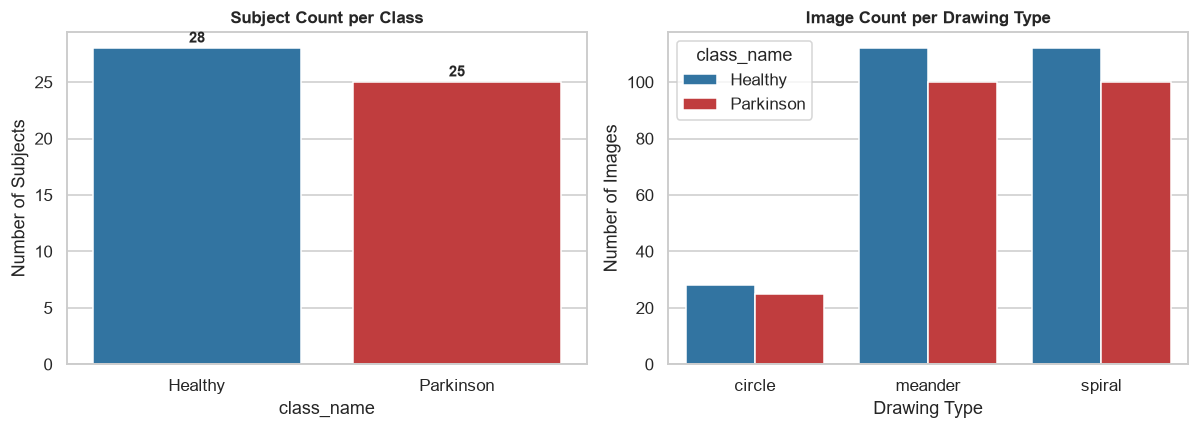

In [3]:
# Summary table of subjects and images by class and drawing type
dist_table = dev_df.groupby(["class_name", "drawing_type"]).size().unstack(fill_value=0)
dist_table["total_images"] = dist_table.sum(axis=1)
dist_table["subjects"] = dev_df.groupby("class_name")["subject_id"].nunique()

display(dist_table)

# Report the balance instead of asserting it in prose
share = dev_df["class_name"].value_counts(normalize=True).mul(100).round(1)
print(f"Image share : {share.to_dict()}")
print(f"Imbalance   : {share.max() / share.min():.2f}:1")

# Visualizing Subject and Image Distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Subject counts
subject_counts = dev_df.groupby("class_name")["subject_id"].nunique()
sns.barplot(
    x=subject_counts.index,
    y=subject_counts.values,
    hue=subject_counts.index,
    palette=COLORS,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Subject Count per Class")
axes[0].set_ylabel("Number of Subjects")
for i, v in enumerate(subject_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# Drawing counts
sns.countplot(data=dev_df, x="drawing_type", hue="class_name", palette=COLORS, ax=axes[1])
axes[1].set_title("Image Count per Drawing Type")
axes[1].set_xlabel("Drawing Type")
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

## 3 - Image Properties & Shortcut Risk Analysis

We inspect non-clinical image metadata (width, height, aspect ratio, file size, color mode) and quantify how much of the label each of them leaks on its own.

### Discussion
Neural networks readily exploit "shortcuts": if one class systematically comes from a different camera or scanner, the model can reach a high score without ever looking at the handwriting. Eyeballing boxplots is not enough to rule this out, so we measure it directly with a **univariate separability AUC** per feature, both overall and within each drawing type.

Interpretation used throughout this project:
- **AUC ≈ 0.50–0.60** — feature carries little class information; shortcut risk is low.
- **AUC ≈ 0.60–0.70** — mild association; worth monitoring, not disqualifying.
- **AUC ≥ 0.70** — metadata alone is substantially predictive. This is a red flag: any reported model performance must then be compared against this metadata-only baseline before it can be attributed to clinical signal.

The aspect ratio distribution is shown here as well, because it determines how much geometric distortion the 224×224 resize in Section 7 introduces.

In [4]:
# Extract image metadata
def get_image_info(filepath: str) -> dict:
    full_path = RAW_DIR / filepath
    with Image.open(full_path) as img:
        width, height = img.size
        mode = img.mode
    return {
        "width": width,
        "height": height,
        "aspect_ratio": width / height,
        "file_size_kb": full_path.stat().st_size / 1024.0,
        "color_mode": mode,
    }


meta_df = pd.concat(
    [dev_df, pd.DataFrame(map(get_image_info, dev_df["filepath"]))], axis=1
)

display(
    meta_df.groupby("class_name")[["width", "height", "aspect_ratio", "file_size_kb"]]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
print("Color modes:", meta_df["color_mode"].value_counts().to_dict())

width                    height                   aspect_ratio  \
              mean     std  min  max    mean     std  min  max         mean   
class_name                                                                    
Healthy     575.21  161.52   40  720  567.49  158.03   45  724         1.01   
Parkinson   601.03  137.56  144  822  589.20  122.48  171  756         1.01   

                             file_size_kb                         
             std   min   max         mean     std    min     max  
class_name                                                        
Healthy     0.05  0.80  1.18       126.34  135.08   2.02  395.07  
Parkinson   0.09  0.64  1.56       287.37   98.30  25.91  464.31

Color modes: {'RGB': 477}


In [5]:
def separability_auc(scores: pd.Series, labels: pd.Series) -> float:
    """Direction-agnostic AUC of a single feature, via rank statistics.

    0.50 means the feature carries no class information; 1.00 means the label
    is fully recoverable from that feature alone.
    """
    ranks = scores.rank().to_numpy()
    is_positive = labels.to_numpy() == 1
    n_pos = int(is_positive.sum())
    n_neg = len(labels) - n_pos
    auc = (ranks[is_positive].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return max(auc, 1 - auc)


SHORTCUT_FEATURES = ["width", "height", "aspect_ratio", "file_size_kb"]

shortcut_auc = pd.DataFrame(
    {
        feature: {
            drawing: separability_auc(group[feature], group["label"])
            for drawing, group in meta_df.groupby("drawing_type")
        }
        | {"overall": separability_auc(meta_df[feature], meta_df["label"])}
        for feature in SHORTCUT_FEATURES
    }
).round(3)

display(shortcut_auc)
print(f"Highest metadata-only AUC: {shortcut_auc.to_numpy().max():.3f}")

,width,height,aspect_ratio,file_size_kb
circle,0.786,0.805,0.714,0.806
meander,0.550,0.548,0.616,0.846
spiral,0.874,0.718,0.585,0.874
overall,0.593,0.539,0.559,0.816


Highest metadata-only AUC: 0.874


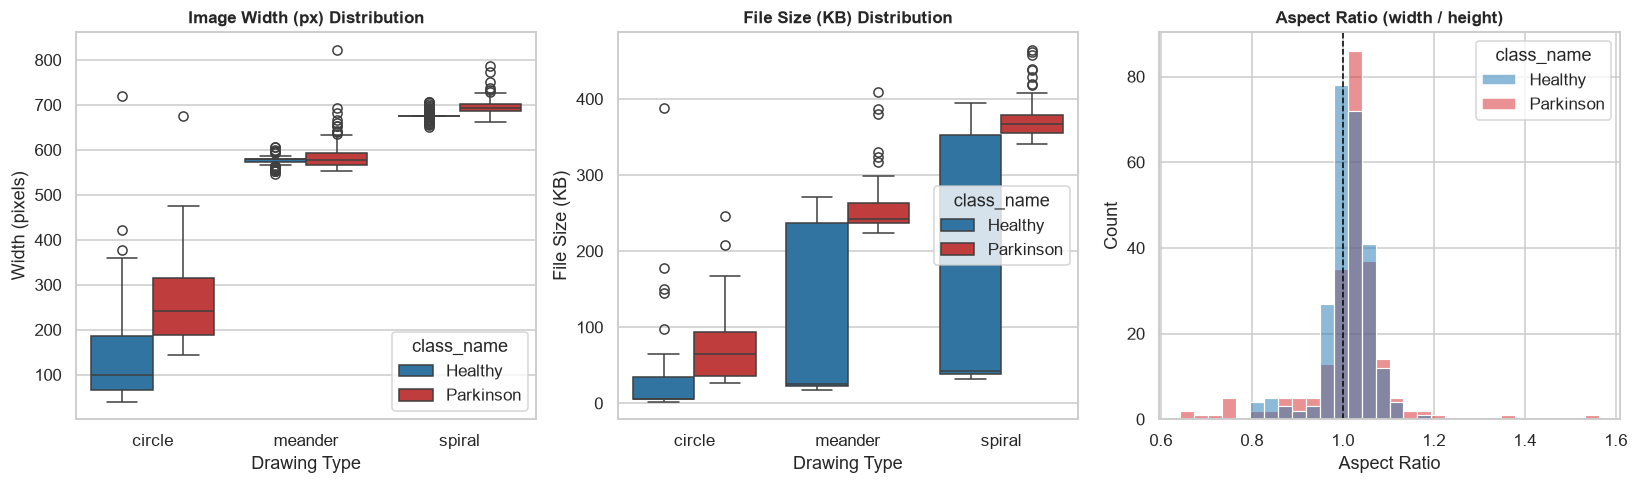

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=meta_df, x="drawing_type", y="width", hue="class_name", palette=COLORS, ax=axes[0])
axes[0].set_title("Image Width (px) Distribution")
axes[0].set_ylabel("Width (pixels)")

sns.boxplot(data=meta_df, x="drawing_type", y="file_size_kb", hue="class_name", palette=COLORS, ax=axes[1])
axes[1].set_title("File Size (KB) Distribution")
axes[1].set_ylabel("File Size (KB)")

sns.histplot(data=meta_df, x="aspect_ratio", hue="class_name", palette=COLORS, bins=30, ax=axes[2])
axes[2].axvline(1.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Aspect Ratio (width / height)")
axes[2].set_xlabel("Aspect Ratio")

for ax in axes[:2]:
    ax.set_xlabel("Drawing Type")

plt.tight_layout()
plt.show()

## 4 - Duplication & Ink Coverage

Two checks that subject-level splitting alone cannot cover: byte-identical duplicate files, and the amount of ink actually drawn on the page.

### Discussion
**Duplicates.** Subject-level splitting protects against a subject appearing on both sides of a split, but not against the *same image file* being stored twice. A duplicate within one subject only inflates that subject's weight; a duplicate **across subjects** is a genuine leakage path, because the identical image can land in both training and validation folds under different subject IDs.

This dataset does contain such duplicates, so `parkindraw.data.splits` derives subject **clusters** from these same file hashes and treats each cluster as one indivisible split unit. The cell below is therefore no longer just a report — it is a **regression check on the split artifacts**: it re-hashes every image and confirms that no duplicate group straddles the dev/holdout boundary or a train/validation boundary in any fold. Every counter it prints must be zero.

The scan covers the full manifest rather than the development set alone. A duplicate spanning dev and holdout would silently compromise the final benchmark, and a dev-only scan cannot see it.

**Ink coverage.** The fraction of dark pixels is the simplest available proxy for what the model is meant to see — stroke length, pressure and tremor-induced overdrawing all increase it. It is deliberately dual-purpose: a strong separation between classes is either real motor signal or an acquisition artifact (pen thickness, scanner contrast), and both possibilities must be known before training rather than discovered after.

In [7]:
# Duplicate detection deliberately spans the FULL manifest, not just the
# development set: a duplicate group straddling the dev/holdout boundary would
# compromise the final benchmark and is invisible to a dev-only check.
# Only file hashes are read here, so no holdout pixels or metadata enter the analysis.
# SHA-256 matches parkindraw.data.splits.hash_images, so the values below are
# directly comparable with the clusters recorded in split_config.json.
hash_by_path = {
    p: hashlib.sha256((RAW_DIR / p).read_bytes()).hexdigest()
    for p in manifest["filepath"]
}
hashed = manifest.assign(image_hash=manifest["filepath"].map(hash_by_path))
meta_df["image_hash"] = meta_df["filepath"].map(hash_by_path)

duplicates = hashed[hashed.duplicated("image_hash", keep=False)].sort_values("image_hash")
subjects_per_group = duplicates.groupby("image_hash")["subject_id"].nunique()

print(f"Byte-identical files : {len(duplicates)} in {len(subjects_per_group)} groups")
print(f"Cross-subject groups : {subjects_per_group.gt(1).sum()} (leakage risk if unhandled)")

# The splitter clusters these subjects so they never straddle a split boundary.
# Verify that guarantee against the written split artifacts, independently.
split_config = json.loads((SPLIT_DIR / "split_config.json").read_text())
print(f"\nDuplicate clusters recorded by the splitter: {split_config['duplicate_clusters']}")

assignments = {"dev/holdout": dict(zip(holdout_df["subject_id"], holdout_df["partition"]))}
for fold_path in sorted(SPLIT_DIR.glob("fold_*.csv")):
    fold = pd.read_csv(fold_path)
    assignments[fold_path.stem] = dict(zip(fold["subject_id"], fold["split"]))

print("\nDuplicate groups straddling a split boundary (must be 0 everywhere):")
for name, assignment in assignments.items():
    sides = duplicates["subject_id"].map(assignment)
    straddling = sides.groupby(duplicates["image_hash"]).nunique().gt(1).sum()
    print(f"  {name:<11}: {straddling}")

if not duplicates.empty:
    display(
        duplicates.groupby("image_hash")
        .agg(subjects=("subject_id", lambda s: sorted(set(s))), files=("filename", list))
        .reset_index(drop=True)
    )

Byte-identical files : 80 in 36 groups
Cross-subject groups : 36 (leakage risk if unhandled)

Duplicate clusters recorded by the splitter: {'P01': ['P01', 'P04', 'P25'], 'P02': ['P02', 'P26'], 'P09': ['P09', 'P27'], 'P13': ['P13', 'P15'], 'P14': ['P14', 'P16']}

Duplicate groups straddling a split boundary (must be 0 everywhere):
  dev/holdout: 0
  fold_0     : 0
  fold_1     : 0
  fold_2     : 0


,subjects,files
0,"[P01, P04, P25]","[mea4-P1.jpg, mea4-P4.jpg, mea4-P25.jpg]"
1,"[P14, P16]","[sp2-P16.jpg, sp2-P14.jpg]"
2,"[P14, P16]","[mea4-P14.jpg, mea4-P16.jpg]"
3,"[P02, P26]","[sp3-P26.jpg, sp3-P2.jpg]"
4,"[P13, P15]","[sp1-P15.jpg, sp1-P13.jpg]"
5,"[P01, P04, P25]","[sp1-P4.jpg, sp1-P25.jpg, sp1-P1.jpg]"
6,"[P02, P26]","[sp2-P2.jpg, sp2-P26.jpg]"
7,"[P14, P16]","[mea1-P16.jpg, mea1-P14.jpg]"
8,"[P01, P04, P25]","[mea1-P25.jpg, mea1-P1.jpg, mea1-P4.jpg]"
9,"[P13, P15]","[mea1-P13.jpg, mea1-P15.jpg]"


Ink-fraction separability AUC: {'circle': np.float64(0.744), 'meander': np.float64(0.702), 'spiral': np.float64(0.707)}


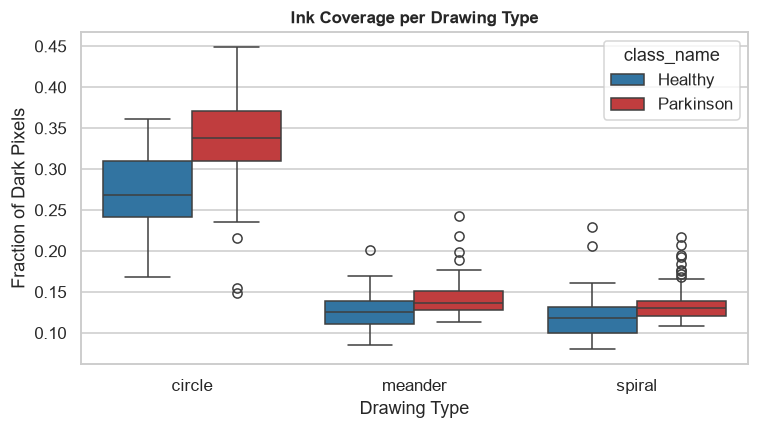

In [8]:
INK_THRESHOLD = 200  # grayscale value below which a pixel counts as ink


def ink_fraction(filepath: str) -> float:
    with Image.open(RAW_DIR / filepath) as img:
        pixels = np.asarray(img.convert("L"))
    return float((pixels < INK_THRESHOLD).mean())


meta_df["ink_fraction"] = [ink_fraction(p) for p in meta_df["filepath"]]

ink_auc = {
    drawing: separability_auc(group["ink_fraction"], group["label"])
    for drawing, group in meta_df.groupby("drawing_type")
}
print("Ink-fraction separability AUC:", {k: round(v, 3) for k, v in ink_auc.items()})

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=meta_df, x="drawing_type", y="ink_fraction", hue="class_name", palette=COLORS, ax=ax)
ax.set_title("Ink Coverage per Drawing Type")
ax.set_xlabel("Drawing Type")
ax.set_ylabel("Fraction of Dark Pixels")

plt.tight_layout()
plt.show()

## 5 - Visual Sample Inspection

We visualize randomly drawn sample drawings (Circle, Meander, Spiral) from Healthy control participants and Parkinson's patients, several per class.

### Discussion
Samples are drawn with a fixed seed rather than taken as the first row of the manifest: a single example per class is easy for the eye to over-generalize from, and manifest order is not random. What to look for:
- **Circle**: Single continuous circular trace per subject. Parkinson drawings frequently exhibit subtle micro-tremors, uneven line spacing, or line hesitation compared to smooth Healthy curves.
- **Meander**: Wave/sinusoidal lines. Tremor and motor instability in Parkinson samples manifest as irregular amplitude and sharp directional changes.
- **Spiral**: Concentric spiral patterns. Distance between loops and stroke continuity serve as key visual indicators of motor impairment.

These are qualitative impressions from a handful of images, not measured effects — they motivate the modeling approach but prove nothing on their own.

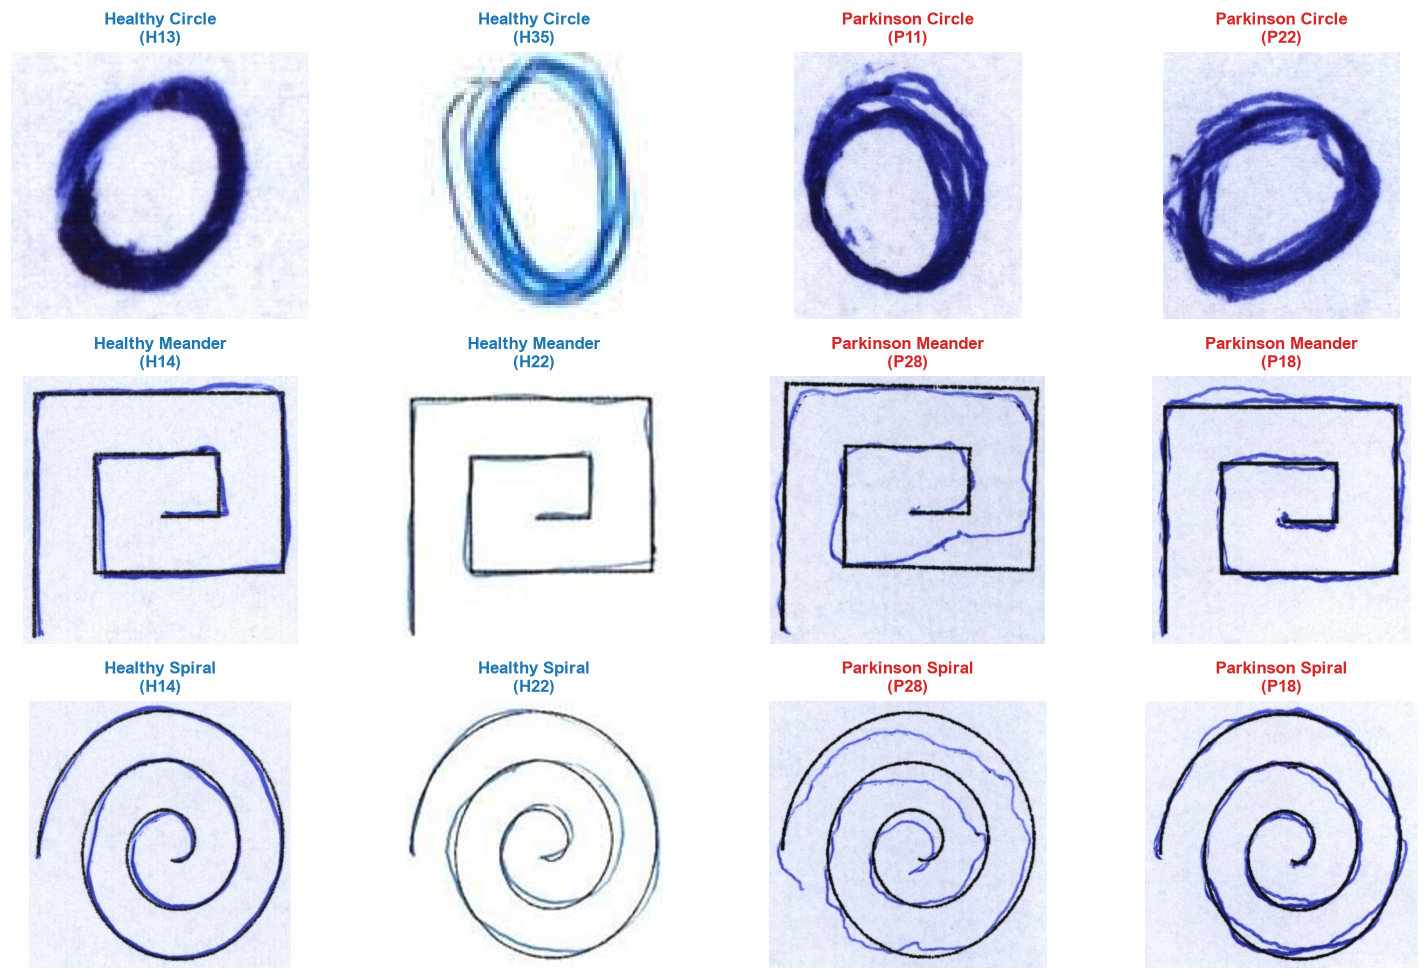

In [9]:
SAMPLES_PER_CLASS = 2

fig, axes = plt.subplots(3, 2 * SAMPLES_PER_CLASS, figsize=(14, 9))

for row, drawing in enumerate(["circle", "meander", "spiral"]):
    subset = dev_df[dev_df["drawing_type"] == drawing]
    for offset, class_name in enumerate(COLORS):
        samples = subset[subset["class_name"] == class_name].sample(
            SAMPLES_PER_CLASS, random_state=SEED
        )
        for i, (_, sample) in enumerate(samples.iterrows()):
            ax = axes[row, offset * SAMPLES_PER_CLASS + i]
            with Image.open(RAW_DIR / sample["filepath"]) as img:
                ax.imshow(img)
            ax.set_title(
                f"{class_name} {drawing.capitalize()}\n({sample['subject_id']})",
                color=COLORS[class_name],
            )
            ax.axis("off")

plt.tight_layout()
plt.show()

## 6 - Parsing & Metadata Integrity Verification

We verify the key data parsing assumptions and rules defined in `parkindraw.data.dataset`.

### Discussion
1. **Folder-based Class Assignment**: All Circle files use the filename prefix `circA-P*.jpg` in both Healthy and Parkinson directories. The parser assigns class labels strictly from the parent directory name (`HealthyCircle` vs `PatientCircle`), never from the filename.
2. **Subject ID Consistency**: Prefix `H` is assigned to Healthy subjects and `P` to Parkinson subjects, regardless of the raw filename token.
3. **Index Override Mapping**: Subject `P08` contains `mea5-P8.jpg` instead of `mea4`; the override rule maps it to drawing index 4 without raising an error. The check below confirms the resulting indices are exactly 1–4 with no gaps or repeats.

In [10]:
EXPECTED_COUNTS = {"circle": 1, "meander": 4, "spiral": 4}

# Every subject must contribute exactly the protocol-defined number of drawings
counts = dev_df.groupby(["subject_id", "drawing_type"]).size().unstack(fill_value=0)
violations = counts[(counts[list(EXPECTED_COUNTS)] != pd.Series(EXPECTED_COUNTS)).any(axis=1)]

print(f"Protocol expected per subject: {EXPECTED_COUNTS}")
if violations.empty:
    print(f"All {len(counts)} development subjects conform.")
else:
    print(f"{len(violations)} subject(s) violate the protocol:")
    display(violations)

# Drawing indices must form a complete 1..n set per subject and drawing type
index_sets = dev_df.groupby(["subject_id", "drawing_type"])["drawing_index"].apply(set)
bad_indices = index_sets[
    [
        indices != set(range(1, EXPECTED_COUNTS[drawing] + 1))
        for indices, (_, drawing) in zip(index_sets, index_sets.index)
    ]
]

print(f"\nSubjects with gapped or duplicated drawing indices: {len(bad_indices)}")
if not bad_indices.empty:
    display(bad_indices)

# Confirm the P08 mea5 -> index 4 override. P08 may land in the holdout after a
# re-split, in which case it is simply out of scope here rather than missing.
OVERRIDE_SUBJECT = "P08"
p08_meanders = dev_df[
    (dev_df["subject_id"] == OVERRIDE_SUBJECT) & (dev_df["drawing_type"] == "meander")
]
if p08_meanders.empty:
    print(f"\n{OVERRIDE_SUBJECT} is in the locked holdout; override not inspected here.")
else:
    print(f"\n{OVERRIDE_SUBJECT} meander index mapping:")
    display(p08_meanders[["filename", "drawing_index", "subject_id"]])

Protocol expected per subject: {'circle': 1, 'meander': 4, 'spiral': 4}
All 53 development subjects conform.

Subjects with gapped or duplicated drawing indices: 0

P08 meander index mapping:


,filename,drawing_index,subject_id
185,mea1-P8.jpg,1,P08
186,mea2-P8.jpg,2,P08
187,mea3-P8.jpg,3,P08
188,mea5-P8.jpg,4,P08


## 7 - Preprocessing Impact Analysis (224x224 Resize)

We evaluate the visual impact of resizing raw images to **224×224 pixels** (standard ResNet-18 input size) with bilinear interpolation.

### Discussion
Direct resizing stretches non-square images into a square frame, so the distortion is worst for the image whose aspect ratio is furthest from 1.0. We therefore inspect that worst case rather than an arbitrary sample: if fine stroke lines survive there, they survive everywhere in the development set. Standard ImageNet normalization follows in the PyTorch pipeline.

If the worst case does show visible stroke degradation, the alternative is aspect-preserving resize with padding — a decision this cell is meant to inform.

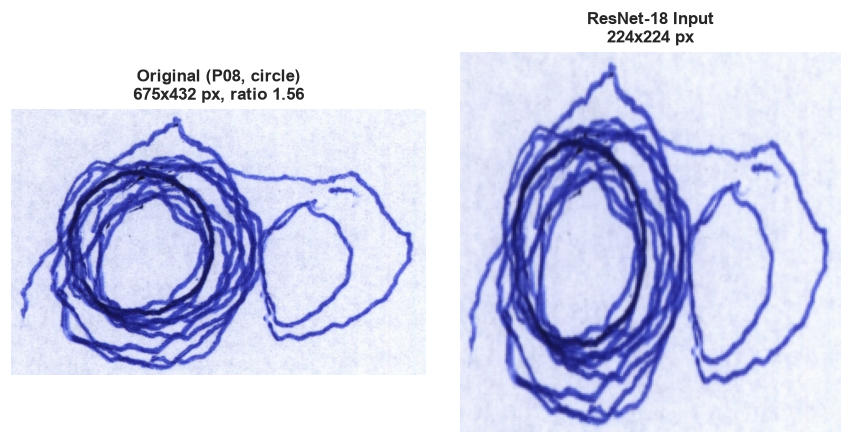

In [11]:
TARGET_SIZE = (224, 224)

# Worst-case distortion: the aspect ratio furthest from square
worst_row = meta_df.loc[(meta_df["aspect_ratio"] - 1).abs().idxmax()]

with Image.open(RAW_DIR / worst_row["filepath"]) as original:
    resized = original.convert("RGB").resize(TARGET_SIZE, Image.Resampling.BILINEAR)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original)
    axes[0].set_title(
        f"Original ({worst_row['subject_id']}, {worst_row['drawing_type']})\n"
        f"{original.size[0]}x{original.size[1]} px, ratio {worst_row['aspect_ratio']:.2f}"
    )
    axes[1].imshow(resized)
    axes[1].set_title(f"ResNet-18 Input\n{TARGET_SIZE[0]}x{TARGET_SIZE[1]} px")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8 - Summary of Key EDA Findings

What this analysis checks and what each result implies for training and evaluation. Measured values are left in the cell outputs rather than repeated here, so this table cannot drift out of sync with the data. Section 9 records the issues that were actually flagged on the current run.

| # | EDA Finding | Impact on Model Training & Evaluation |
|---|---|---|
| 1 | **Class balance** — near-even Healthy/Parkinson split at both subject and image level *(Section 2)*. | Standard cross-entropy loss and unweighted ROC-AUC are appropriate; no class reweighting needed. |
| 2 | **Metadata shortcut risk** — univariate separability AUC measured for width, height, aspect ratio and file size, overall and per drawing type *(Section 3)*. | Any feature at AUC ≥ 0.70 becomes a mandatory metadata-only baseline: the model must beat it before its score can be read as clinical signal. |
| 3 | **Duplication** — byte-level hash check over the full manifest, plus a boundary check against the written split artifacts *(Section 4)*. | Cross-subject duplicates defeat subject-level splitting. The splitter now clusters the affected subjects; this cell is the regression check that the guarantee still holds. |
| 4 | **Ink coverage** — dark-pixel fraction compared across classes with its own separability AUC *(Section 4)*. | Establishes a cheap non-deep baseline, and flags whether apparent signal could stem from pen or scanner differences. |
| 5 | **Parsing integrity** — every dev subject matches the (1 Circle, 4 Meanders, 4 Spirals) protocol with complete 1..n indices *(Section 6)*. | The manifest generator is deterministic and reliable for constructing leakage-safe cross-validation folds. |
| 6 | **224×224 resizing** — inspected on the most distorted image in the set *(Section 7)*. | If strokes survive the worst case, plain square resize is safe; otherwise switch to aspect-preserving resize with padding. |
| 7 | **Strict holdout lock** — holdout subjects remain unobserved, enforced by disjointness and completeness assertions *(Section 1)*. | Final evaluation on the locked subjects provides an unbiased performance benchmark. |

## 9 - Issue Register

Two issues were raised by the original run of this notebook. One has since been remediated; the other remains open and constrains how model results may be reported.

### ✅ Resolved — Cross-subject duplicate images (Section 4)

The scan found byte-identical files shared across distinct Parkinson subject IDs. All affected subjects are Parkinson, so the class label itself was never leaked, but subject-level splitting was defeated: the identical file could appear in a training fold under one ID and in a validation fold under another, making validation scores partly a measure of memorization.

Re-running the check across the **full** manifest (the original run covered only the development set) surfaced more affected subjects than the dev-only scan had shown, including groups that straddled the dev/holdout boundary — which would have compromised the final benchmark.

*Remediation.* `parkindraw.data.splits` now derives subject clusters from file hashes at runtime and splits on clusters instead of raw subject IDs, so every set of duplicate-linked subjects stays inside one partition and one fold. The clusters are recorded in `split_config.json`, and `verify_no_leakage` validates the written splits against the image hashes themselves rather than against the cluster map used to build them — an incomplete cluster map can no longer pass silently. The boundary counters printed in Section 4 are the standing regression check.

### ⚠️ Open — File size is a strong shortcut (Section 3)

`file_size_kb` separates the classes far above the 0.70 red-flag threshold, both overall and within drawing types, and mean file size differs several-fold between classes. This points to different acquisition or compression settings per class rather than anything clinical. Width and height are also strongly separable *within* each drawing type. See the AUC table for the values on this run.

*Action:* a classifier could reach roughly this AUC from file metadata alone. Report that metadata-only baseline alongside every model result, and consider preprocessing that neutralizes the artifact (fixed re-encoding, aspect-preserving resize) so the network cannot key on compression footprint. **This is not yet implemented.**

**Related caveat.** Ink coverage also separates the classes appreciably. That is the expected direction for genuine motor impairment, but while the file-size shortcut is unresolved it cannot be distinguished from a pen-thickness or scanner-contrast artifact.

## 10 - Executive Conclusion & Actionable Recommendations

### Executive Summary
The exploratory analysis of the NewHandPD development set confirms a well-balanced target distribution (see Section 2 for the counts on this run) and a strict structure of 1 Circle, 4 Meanders, and 4 Spirals per subject. Resizing images to 224×224 pixels for ResNet-18 preserves handwriting stroke structures without critical information loss.

Two **critical issues** were identified. The first has been remediated; the second still gates how results may be interpreted:

1. **Cross-subject image duplication — resolved.** Byte-identical files spanned distinct Parkinson subject IDs, which defeated subject-level cross-validation and would have produced optimistic memorization scores. The splitter now derives duplicate clusters from file hashes and keeps each cluster inside a single partition and fold.
2. **Metadata & non-clinical shortcuts — open.** Image file size exhibits strong class separability (Section 3). A naive model could achieve high accuracy solely by exploiting compression artifacts rather than clinical motor features.

---

### Actionable Recommendations for Machine Learning Pipeline

1. ~~**Fix subject-level data splits**~~ — **done.** `parkindraw.data.splits` clusters duplicate-linked subjects into a single split unit, derives those clusters from file hashes at runtime so the list cannot go stale, and verifies the written splits against the hashes independently of the cluster map used to build them.
2. **Mandatory metadata baseline** — establish a metadata-only baseline model (file size and resolution features) *before* neural network training. The ResNet-18 model must clearly exceed it to demonstrate genuine clinical learning.
3. **Standardized preprocessing** — implement strict image re-encoding (fixed PNG compression or uniform JPEG quality) during dataset preprocessing to strip the compression-footprint shortcut.
4. **Preserve locked holdout** — keep the holdout subjects strictly unobserved until final post-optimization evaluation.

Recommendations 2 and 3 remain outstanding and should be addressed in the preprocessing and baseline stages.